In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

In [104]:
df = pd.read_csv("/content/final_data.csv")
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,...,age_group,total_contacts,contact_pressure,high_contact_flag,never_contacted_before,recent_contact,pdays_bucket,prev_success,prev_contact_flag,engagement_score
0,30,unemployed,married,primary,0,0.282211,0,0,cellular,19,...,Young,1,1.0,0,1,0,never,0,0,0
1,33,services,married,secondary,0,1.209846,1,1,cellular,11,...,Adult,5,0.2,0,0,0,never,0,1,0
2,35,management,single,tertiary,0,0.130429,1,0,cellular,16,...,Adult,2,0.5,0,0,0,never,0,1,0
3,30,management,married,tertiary,0,0.174936,1,1,unknown,3,...,Young,4,4.0,1,1,0,never,0,0,0
4,59,blue-collar,married,secondary,0,-0.445382,1,0,unknown,5,...,Senior,1,1.0,0,1,0,never,0,0,0


In [105]:
df.shape

(4521, 28)

In [106]:
x = df.drop('y', axis=1)
y = df['y']

## **Splitting the dataset**

In [107]:

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=42)

In [108]:
x_train = pd.get_dummies(x_train, drop_first=True)
x_test = pd.get_dummies(x_test, drop_first=True)

# Aligning columns to ensure that the training and test datasets
# have exactly the same feature columns in the same order before making predictions.

# This happens as we have done one hot encoding
x_train, x_test = x_train.align(x_test, join='left', axis=1, fill_value=0)

Importing the evaluation metrics

In [109]:
# Evaluation Matrics

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

def evaluate_model(y_true, probs, preds, name):

    cm = confusion_matrix(y_true, preds)
    return cm

Function to plot Confusion Matrix

In [110]:
# Confusion Matrix Code

def plot_confusion_matrix(cm, title):

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=["No", "Yes"],
        yticklabels=["No", "Yes"]
    )

    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

Function to plot ROC-AUC Curve

In [111]:
from sklearn.metrics import roc_curve

def plot_roc(y_true, probs, title):

    fpr, tpr, _ = roc_curve(y_true, probs)

    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc_score(y_true, probs):.3f})")
    plt.plot([0,1], [0,1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.show()

Function for the classification report

In [112]:
from sklearn.metrics import classification_report

def print_classification_report(y_true, y_pred, model_name):
    print(f"\n Classification Report — {model_name}")
    print("-" * 50)

    report = classification_report(
        y_true,
        y_pred,
        target_names=["Not Subscribe", "Subscribe"]
    )

    print(report)

## **Implementing Random Forest Model**

In [113]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(x_train, y_train)

rf_probs = rf_model.predict_proba(x_test)[:,1]
rf_pred = (rf_probs >= 0.5).astype(int)

Calling all the functions for checking the performance

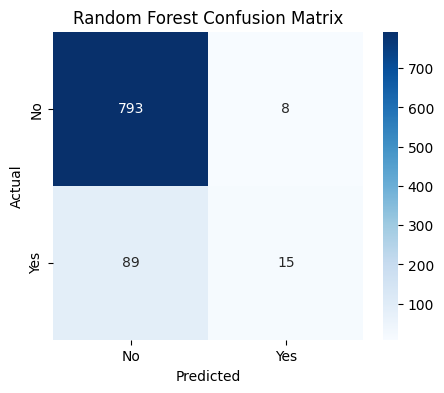

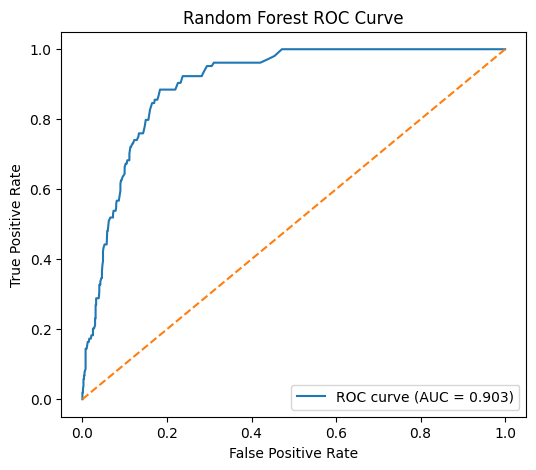


 Classification Report — Random Forest
--------------------------------------------------
               precision    recall  f1-score   support

Not Subscribe       0.90      0.99      0.94       801
    Subscribe       0.65      0.14      0.24       104

     accuracy                           0.89       905
    macro avg       0.78      0.57      0.59       905
 weighted avg       0.87      0.89      0.86       905



In [114]:
rf_preds = (rf_probs >= 0.5).astype(int)

cm = evaluate_model(y_test, rf_probs, rf_preds, "Random Forest")

plot_confusion_matrix(cm, "Random Forest Confusion Matrix")
plot_roc(y_test, rf_probs, "Random Forest ROC Curve")

print_classification_report(y_test, rf_preds, "Random Forest")

### **Now implementing SVM model**

In [115]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

svm_model = SVC(
    kernel='rbf',
    probability=True,
    class_weight='balanced',
    random_state=42
)

svm_model.fit(x_train_scaled, y_train)

svm_probs = svm_model.predict_proba(x_test_scaled)[:,1]
svm_pred = (svm_probs >= 0.5).astype(int)

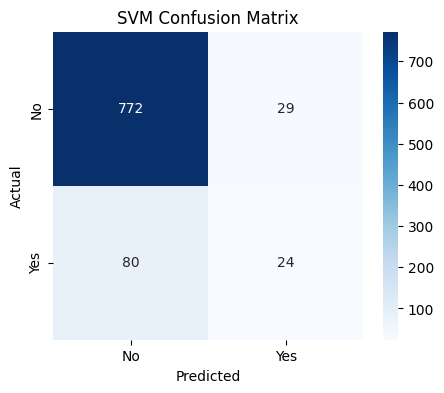

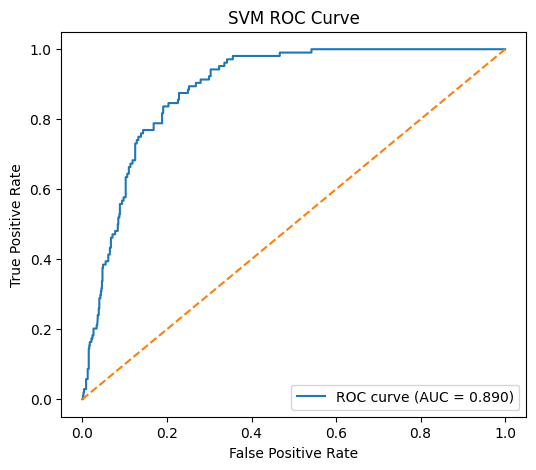


 Classification Report — Support Vector Machine
--------------------------------------------------
               precision    recall  f1-score   support

Not Subscribe       0.91      0.96      0.93       801
    Subscribe       0.45      0.23      0.31       104

     accuracy                           0.88       905
    macro avg       0.68      0.60      0.62       905
 weighted avg       0.85      0.88      0.86       905



In [116]:
svm_pred = (svm_probs >= 0.5).astype(int)

cm = evaluate_model(y_test, svm_probs, svm_pred, "Support Vector Machine SVM")

plot_confusion_matrix(cm, "SVM Confusion Matrix")
plot_roc(y_test, svm_probs, "SVM ROC Curve")

print_classification_report(y_test, svm_pred, "Support Vector Machine")